In [ ]:
# Modules we'll use
import pandas as pd
import numpy as np
import seaborn as sns
import datetime

# Read in our data
import kagglehub
from kagglehub import KaggleDatasetAdapter

landslides = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "nasa/landslide-events",
    "catalog.csv",
    pandas_kwargs={
        "encoding": "utf-8",
        "low_memory": False,
    }
)

# set seed for reproducibility
np.random.seed(0)
landslides.head()

,id,date,time,continent_code,country_name,country_code,state/province,population,city/town,distance,...,geolocation,hazard_type,landslide_type,landslide_size,trigger,storm_name,injuries,fatalities,source_name,source_link
0,34,3/2/07,Night,NaN,United States,US,Virginia,16000,Cherry Hill,3.40765,...,"(38.600900000000003, -77.268199999999993)",Landslide,Landslide,Small,Rain,NaN,NaN,NaN,NBC 4 news,http://www.nbc4.com/news/11186871/detail.html
1,42,3/22/07,NaN,NaN,United States,US,Ohio,17288,New Philadelphia,3.33522,...,"(40.517499999999998, -81.430499999999995)",Landslide,Landslide,Small,Rain,NaN,NaN,NaN,Canton Rep.com,http://www.cantonrep.com/index.php?ID=345054&C...
2,56,4/6/07,NaN,NaN,United States,US,Pennsylvania,15930,Wilkinsburg,2.91977,...,"(40.4377, -79.915999999999997)",Landslide,Landslide,Small,Rain,NaN,NaN,NaN,The Pittsburgh Channel.com,https://web.archive.org/web/20080423132842/htt...
3,59,4/14/07,NaN,NaN,Canada,CA,Quebec,42786,Châteauguay,2.98682,...,"(45.322600000000001, -73.777100000000004)",Landslide,Riverbank collapse,Small,Rain,NaN,NaN,NaN,Le Soleil,http://www.hebdos.net/lsc/edition162007/articl...
4,61,4/15/07,NaN,NaN,United States,US,Kentucky,6903,Pikeville,5.66542,...,"(37.432499999999997, -82.493099999999998)",Landslide,Landslide,Small,Downpour,NaN,NaN,0.0,Matthew Crawford (KGS),NaN


# Check the data type of our date column

We'll be working with the "date" column from the `landslides` dataframe. Let's make sure it actually looks like it contains dates.

In [4]:
landslides['date'].head()

0     3/2/07
1    3/22/07
2     4/6/07
3    4/14/07
4    4/15/07
Name: date, dtype: str

Notice that at the bottom of the output of `head()`, you can see that it says that the data type of this column is "object".

However, the actual dtype for dates is `datetime64`. Therefore it looks like our DataFrame is not recognizing dates appropriately (treated as `str`).

In [5]:
landslides['date'].dtype

<StringDtype(storage='python', na_value=nan)>

# Convert our date columns to datetime

Now that we know that our date column isn't being recognized as a date, it's time to convert it so that it is recognized as a date.

The basic idea is that you need to point out which parts of the date are where and what punctuation is between them.

There are lots of possible parts of a date, but the most common are `%d` for day, `%m` for month, `%y` for a two-digit year and `%Y` for a four digit year.

```text
1/17/07 has the format "%m/%d/%y"
17-1-2007 has the format "%d-%m-%Y"
```

For our example, the format is "month/day/two-digit year", so we will format it accordingly to parse our dates.

In [ ]:
# Create a new column, date_parsed, with the parsed dates
landslides['date_parsed'] = pd.to_datetime(landslides['date'], format="%m/%d/%y")

In [7]:
landslides['date_parsed'].head()

0   2007-03-02
1   2007-03-22
2   2007-04-06
3   2007-04-14
4   2007-04-15
Name: date_parsed, dtype: datetime64[us]

# What if I run into an error with multiple date formats?

While we're specifying the date format here, sometimes you'll run into an error when there are multiple date formats in a single column.

If that happens, you can have pandas try to infer what the right date format should be. You can do that like so:

In [ ]:
landslides['date_parsed'] = pd.to_datetime(landslides['Date'], infer_datetime_format=True)

However, it is not recommended to always use `infer_datetime_format=True`, since pandas won't always been able to figure out the correct date format, especially if someone has gotten creative with data entry, and it's much slower than specifying the exact format of the dates.

# Select the day of the month

Now that we have a column of parsed dates, we can extract information like the day of the month that a landslide occurred.

In [ ]:
# Get the day of the month from the date_parsed column
day_of_month_landslides = landslides['date_parsed'].dt.day # Extracts the day of the month (1–31) from each value in date_parsed. .dt accesses pandas datetime properties, and .day selects the day number.
day_of_month_landslides.head()

0     2.0
1    22.0
2     6.0
3    14.0
4    15.0
Name: date_parsed, dtype: float64

# Plot the day of the month to check the date parsing

One of the biggest dangers in parsing dates is mixing up the months and days. The `to_datetime()` function does have very helpful error messages, but it doesn't hurt to double-check that the days of the month we've extracted make sense.

To do this, let's plot a histogram of the days of the month. We expect it to have values between 1 and 31 and, since there's no reason to suppose the landslides are more common on some days of the month than others, a relatively even distribution. (With a dip on 31 because not all months have 31 days.) Let's see if that's the case:

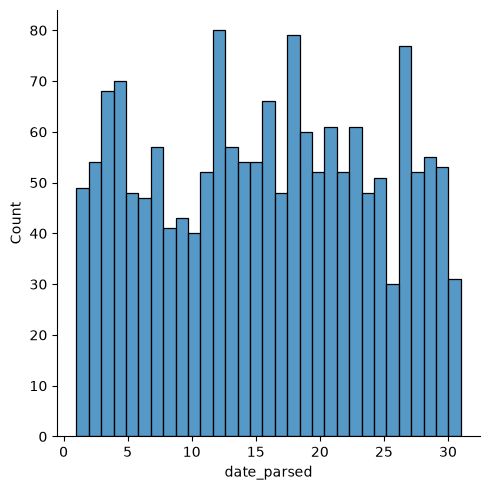

In [ ]:
# Remove na's
day_of_month_landslides = day_of_month_landslides.dropna()

# Plot the day of the month
sns.displot(day_of_month_landslides, kde=False, bins=31) # Plot day_of_month_landslides without kernel density estimation, split into 31 bars (to approximate 31 days in a month)

The histogram corresponds to a typical monthly distribuiton, lgtm.